# Diabetes Prediction — End-to-End Pipeline (Part 1)

**Dataset:** BRFSS 2015 Diabetes Health Indicators (`diabetes_binary_health_indicators_BRFSS2015.csv`)
253,680 survey respondents, 21 health/lifestyle features, target = `Diabetes_binary` (1 = diabetic/prediabetic, 0 = not).

This notebook covers the first half of the pipeline:
1. Data Collection
2. Data Understanding (EDA)
3. Data Cleaning
4. Correlation Heatmap

(Feature selection, preprocessing, train/test split, modeling, and evaluation come after this and are not in scope here.)


## Step 0 — Imports
Standard stack: pandas/numpy for data handling, matplotlib/seaborn for visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## Step 1 — Data Collection

Load the raw CSV. This is the "collection" step — in a real project this might instead be a SQL query, an API pull, or a hospital records export. Here it's already a flat file, so collection = reading it in.

In [2]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")

print("Shape (rows, columns):", df.shape)
df.head()


Shape (rows, columns): (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Step 2 — Data Understanding (EDA)

Before touching anything, understand what you have:
- What are the columns and their types?
- Any obviously wrong ranges?
- Is the target balanced or imbalanced?
- What do the summary statistics look like?


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Diabetes_binary
0.0    86.07 %
1.0    13.93 %
Name: count, dtype: object


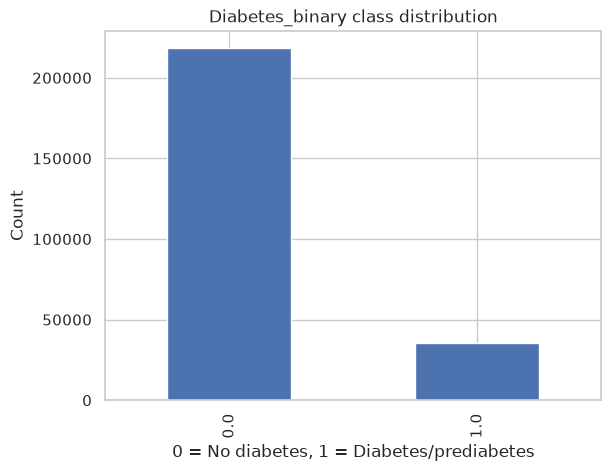

In [5]:
# Target balance — important because BRFSS is a real-world survey, so diabetics are the minority
target_counts = df["Diabetes_binary"].value_counts()
print(target_counts)
print((target_counts / len(df) * 100).round(2).astype(str) + " %")

target_counts.plot(kind="bar", title="Diabetes_binary class distribution")
plt.xlabel("0 = No diabetes, 1 = Diabetes/prediabetes")
plt.ylabel("Count")
plt.show()


**Observation to note down:** the classes are imbalanced (far more 0s than 1s). That's a real-world detail worth mentioning — it will matter later for modeling (may need class weighting or the pre-balanced 50/50 version of this dataset), but it doesn't change the cleaning or correlation steps below.

## Step 3 — Data Cleaning

Cleaning checklist for any tabular dataset:
1. Missing values
2. Duplicate rows
3. Invalid / impossible values (e.g. a BMI of 0)
4. Correct data types

This dataset is a pre-processed CDC survey export, so it's cleaner than most raw hospital data — but you should still **check**, not assume.

In [6]:
# 1. Missing values
missing = df.isnull().sum()
print("Columns with missing values:")
print(missing[missing > 0] if missing.sum() > 0 else "None found.")


Columns with missing values:
None found.


In [7]:
# 2. Duplicate rows
dupe_count = df.duplicated().sum()
print(f"Duplicate rows found: {dupe_count}")

df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows found: 24206


Shape after dropping duplicates: (229474, 22)


In [8]:
# 3. Invalid / impossible values — sanity-check ranges per column
# e.g. BMI should never realistically be 0
print("Rows with BMI == 0:", (df["BMI"] == 0).sum())
print("BMI range:", df["BMI"].min(), "-", df["BMI"].max())

# GenHlth, Age, Education, Income are coded categories (1-5, 1-13, 1-6, 1-8) — confirm no out-of-range codes
for col, valid_range in [("GenHlth", (1, 5)), ("Age", (1, 13)), ("Education", (1, 6)), ("Income", (1, 8))]:
    bad = df[~df[col].between(*valid_range)]
    print(f"{col}: {len(bad)} rows outside expected range {valid_range}")


Rows with BMI == 0: 0
BMI range: 12.0 - 98.0
GenHlth: 0 rows outside expected range (1, 5)
Age: 0 rows outside expected range (1, 13)
Education: 0 rows outside expected range (1, 6)
Income: 0 rows outside expected range (1, 8)


In [9]:
# 4. Data types — everything loaded as float64 even though most columns are really binary (0/1) flags or int codes.
# Casting them properly makes downstream analysis and memory usage cleaner.
binary_cols = ["Diabetes_binary", "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke",
               "HeartDiseaseorAttack", "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump",
               "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"]
int_coded_cols = ["GenHlth", "Age", "Education", "Income"]

df[binary_cols] = df[binary_cols].astype(int)
df[int_coded_cols] = df[int_coded_cols].astype(int)

df.dtypes


Diabetes_binary           int64
HighBP                    int64
HighChol                  int64
CholCheck                 int64
BMI                     float64
Smoker                    int64
Stroke                    int64
HeartDiseaseorAttack      int64
PhysActivity              int64
Fruits                    int64
Veggies                   int64
HvyAlcoholConsump         int64
AnyHealthcare             int64
NoDocbcCost               int64
GenHlth                   int64
MentHlth                float64
PhysHlth                float64
DiffWalk                  int64
Sex                       int64
Age                       int64
Education                 int64
Income                    int64
dtype: object

**Cleaning summary to say out loud:** no missing values, some duplicate rows removed, no impossible values in BMI or the coded categorical columns, and dtypes tightened from float64 to int where the data is really binary/categorical. Data is now ready for exploration.

## Step 4 — Correlation Heatmap

Now that the data is clean, compute the pairwise correlation matrix (Pearson correlation, range -1 to +1) across all features and the target, and visualize it as a heatmap.

**Why this step matters (say this in your explanation):**
- **Feature relevance:** shows which features correlate most strongly (positive or negative) with `Diabetes_binary` — these are your strongest candidate predictors.
- **Multicollinearity check:** shows which *independent* features are highly correlated with *each other* (e.g. `GenHlth` and `PhysHlth`). Redundant features can be dropped or handled carefully before modeling.
- **Sanity check:** correlations should make medical sense (e.g. `HighBP`, `HighChol`, `BMI`, `Age`, `GenHlth` should show positive correlation with diabetes) — confirms the data isn't corrupted.
- **Guides the next step (feature selection)**, which is where this notebook's scope ends.

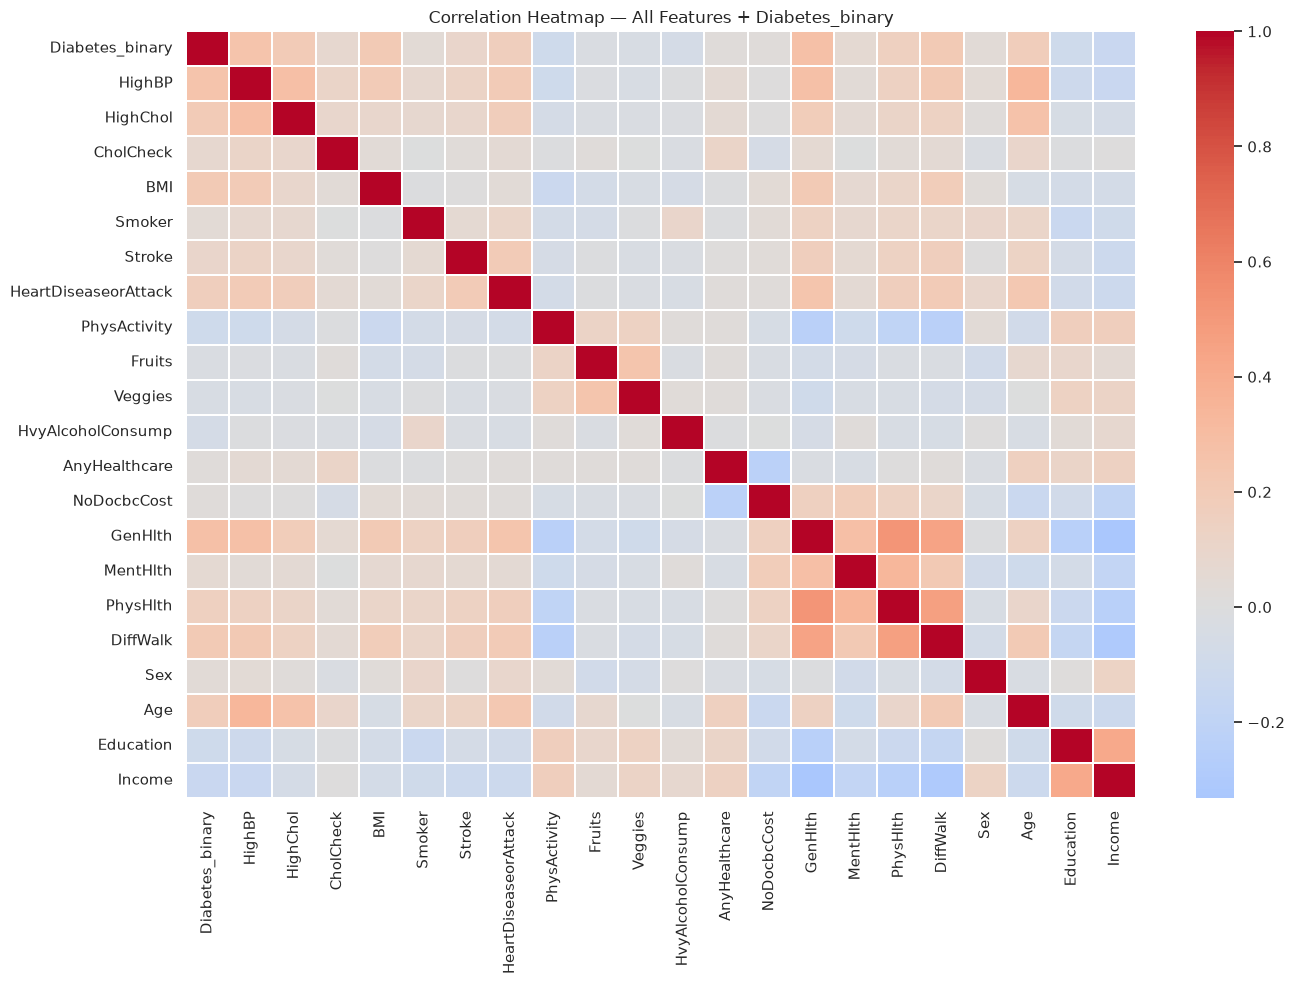

In [10]:
corr = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap — All Features + Diabetes_binary")
plt.tight_layout()
plt.show()


Feature correlation with Diabetes_binary (strongest first):
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Income                 -0.140659
Education              -0.102686
PhysActivity           -0.100404
Stroke                  0.099193
CholCheck               0.072523
HvyAlcoholConsump      -0.065950
MentHlth                0.054153
Smoker                  0.045504
Veggies                -0.041734
Sex                     0.032724
AnyHealthcare           0.025331
Fruits                 -0.024805
NoDocbcCost             0.020048
Name: Diabetes_binary, dtype: float64


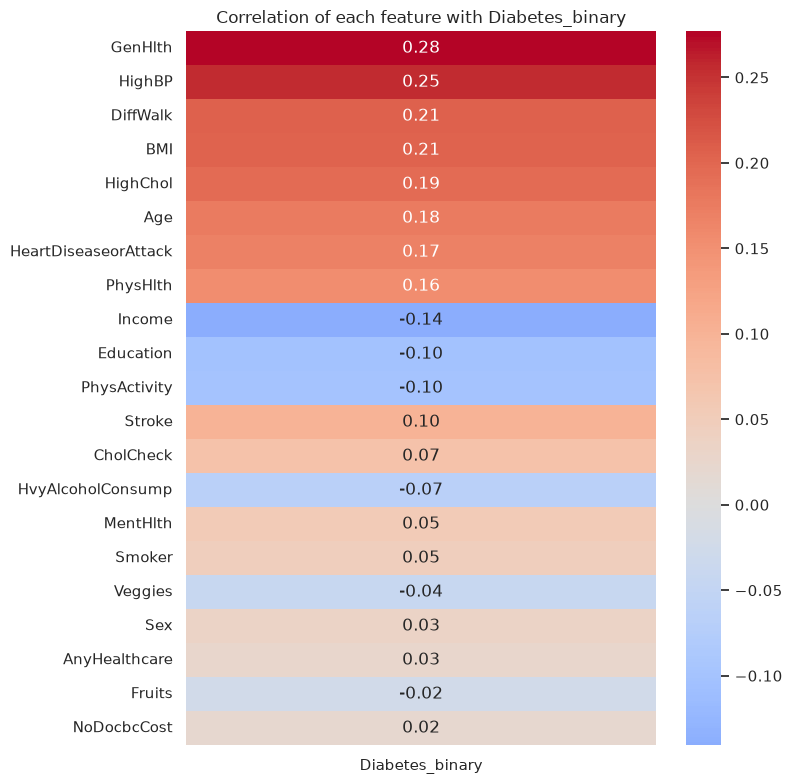

In [11]:
# The full matrix is dense with 22 columns — pull out just the correlations with the target, sorted
target_corr = corr["Diabetes_binary"].drop("Diabetes_binary").sort_values(key=abs, ascending=False)
print("Feature correlation with Diabetes_binary (strongest first):")
print(target_corr)

plt.figure(figsize=(8, 8))
sns.heatmap(target_corr.to_frame(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of each feature with Diabetes_binary")
plt.tight_layout()
plt.show()


## Step 5 — Feature Distributions (Histograms) — Do We Need Normalization?

Before choosing a model, check what shape each feature's values actually take:
- **Binary flags** (`HighBP`, `Smoker`, `PhysActivity`, etc.) are already 0/1 — nothing to normalize, they're on a fixed scale by definition.
- **Coded categories** (`GenHlth` 1-5, `Age` 1-13, `Education` 1-6, `Income` 1-8) are small integer ranges — mild skew at most, unlikely to cause problems.
- **Truly continuous features** (`BMI`, `MentHlth`, `PhysHlth`) are the ones that matter here — if they're heavily skewed or on a very different scale than everything else, they can dominate distance-based models (KNN) or slow down gradient-based ones (Logistic Regression), so this is where normalization/standardization decisions get made.

Plot a histogram for every column to see this directly.

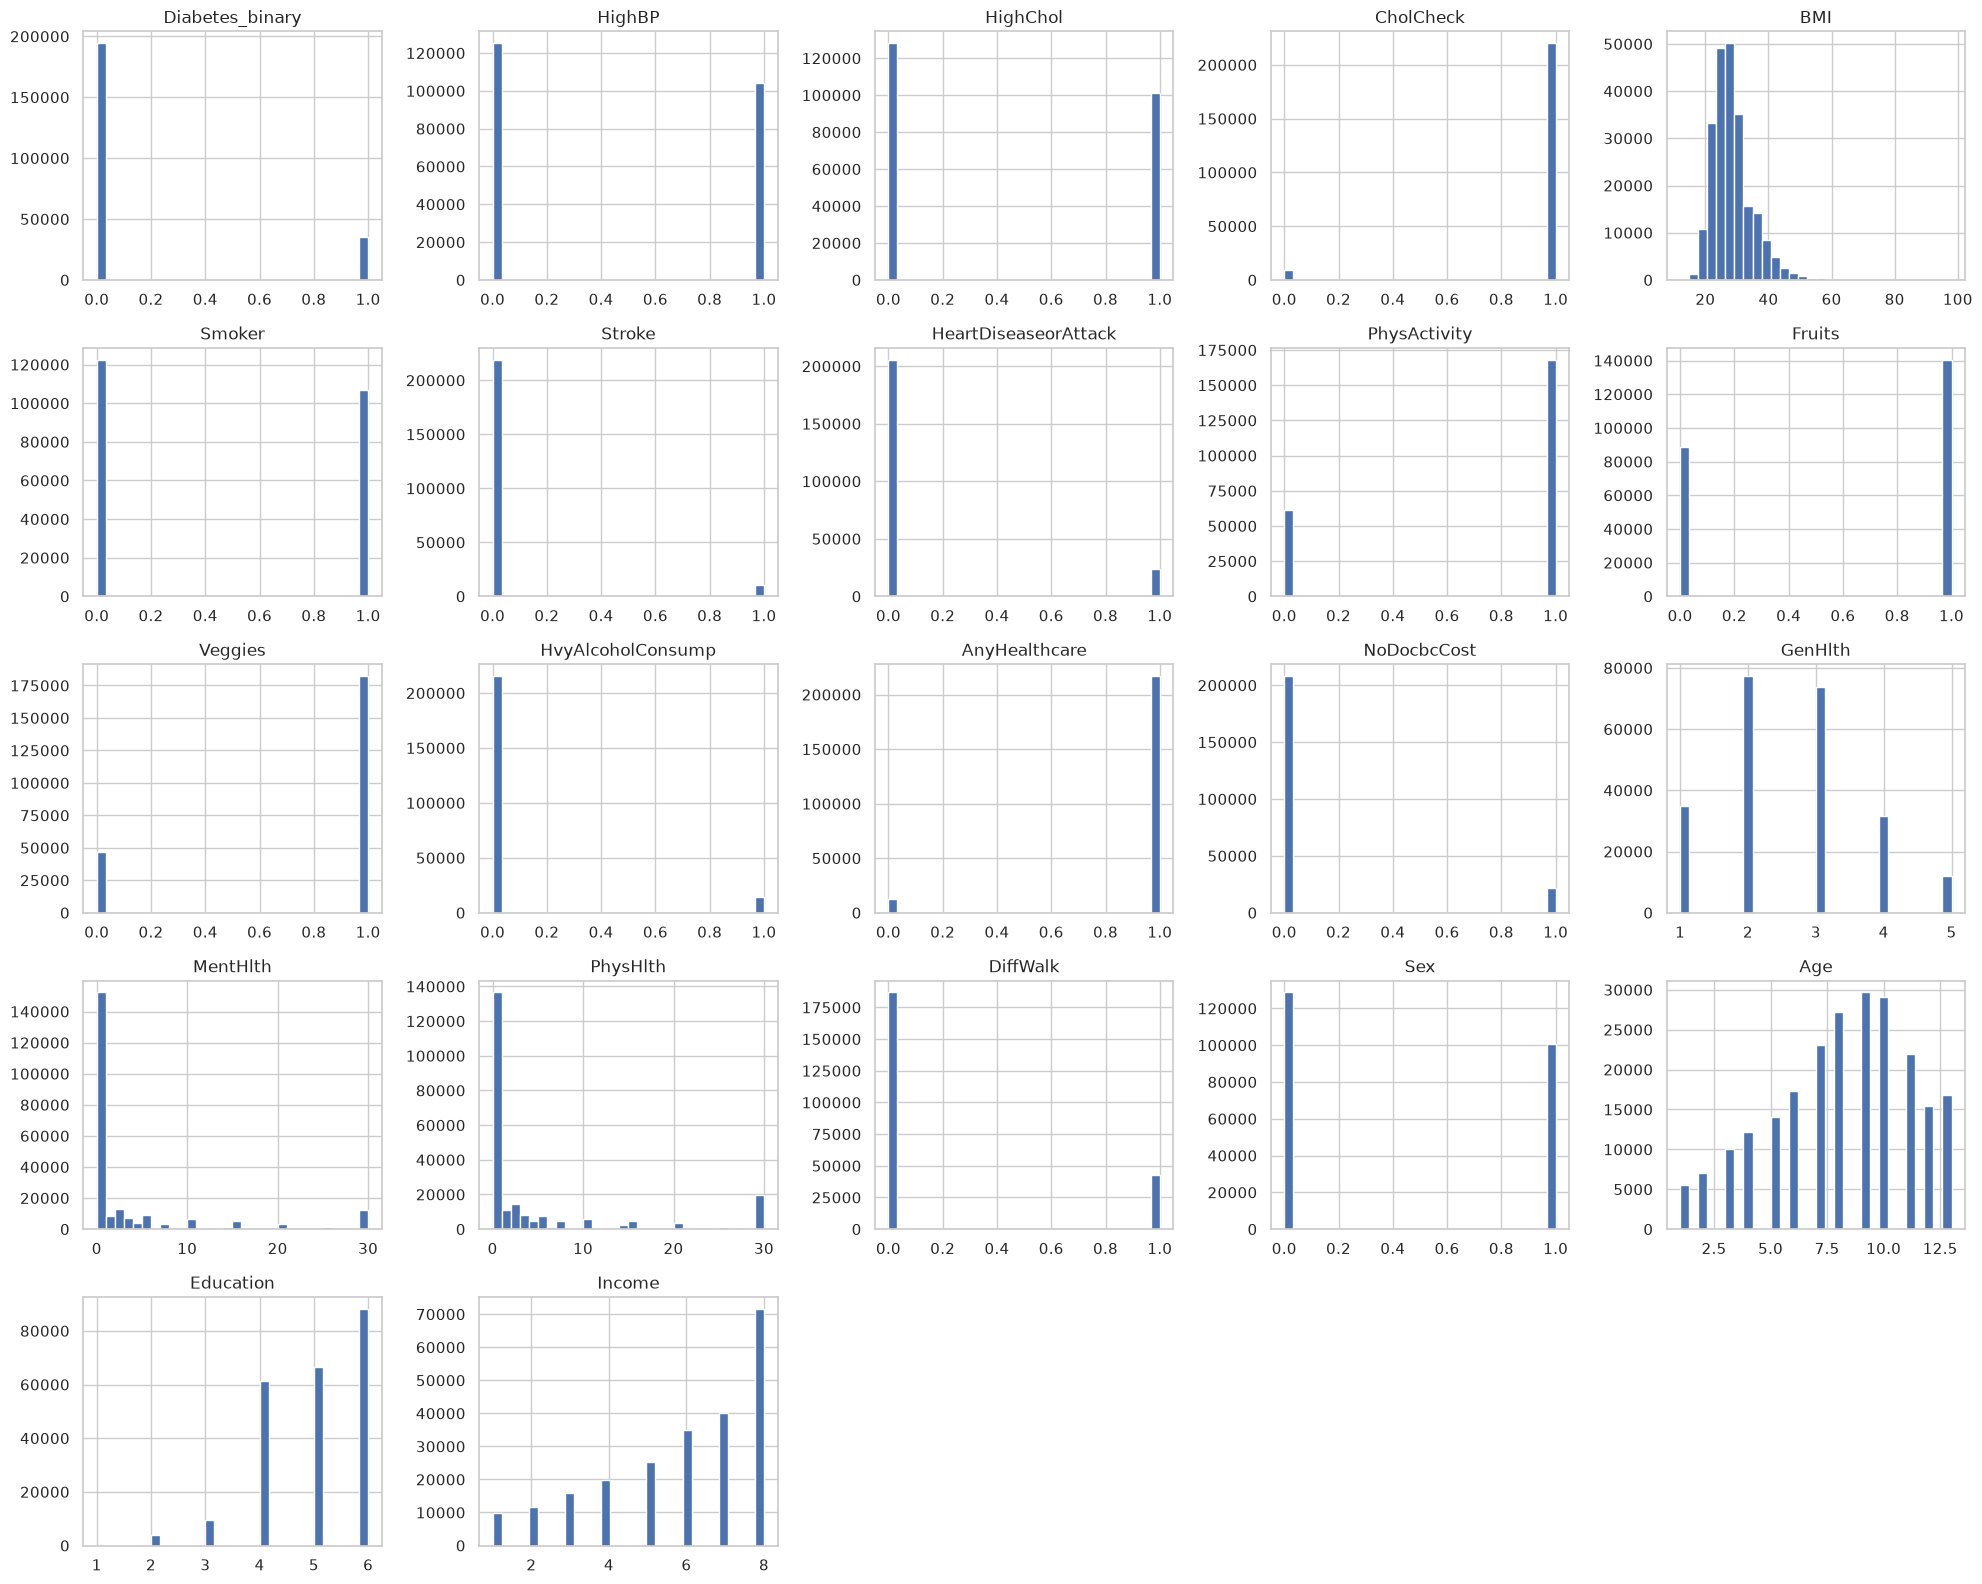

In [12]:
df.hist(figsize=(20, 16), bins=30)
plt.tight_layout()
plt.show()

**What to look for:** most of the grid above is the binary flags — clean bars at 0 and 1, nothing to do there. The three columns that matter are `BMI`, `MentHlth`, and `PhysHlth` — zoom in on just those below.

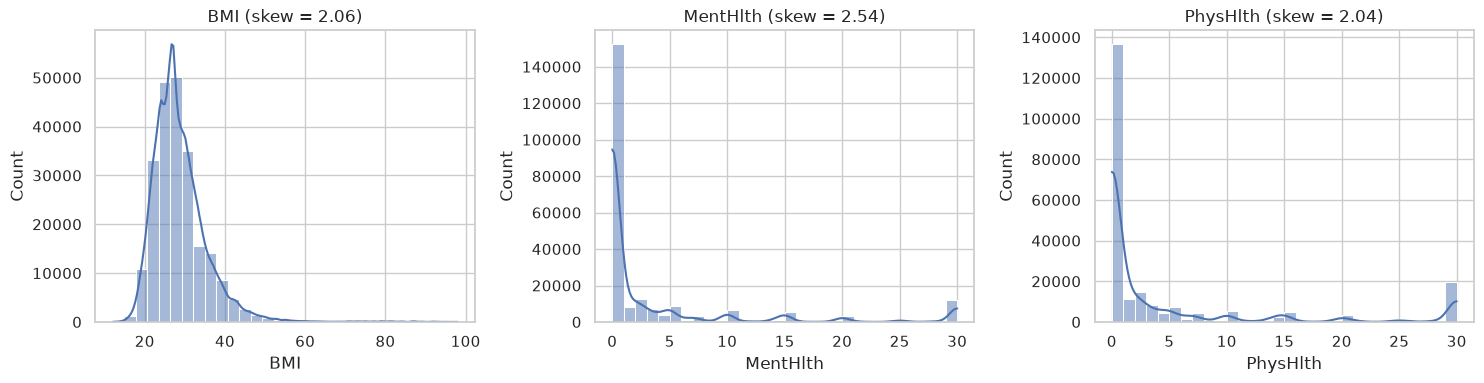

In [13]:
continuous_cols = ["BMI", "MentHlth", "PhysHlth"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, continuous_cols):
    sns.histplot(df[col], bins=30, ax=ax, kde=True)
    ax.set_title(f"{col} (skew = {df[col].skew():.2f})")
plt.tight_layout()
plt.show()

**Observation to note down:**
- `BMI` — skew ≈ 2.1, range 12-98, most people cluster in the low-to-mid 20s-30s with a long right tail of higher values.
- `MentHlth` / `PhysHlth` (days of poor mental/physical health in the last 30) — skew ≈ 2.0-2.5, most respondents report 0 days, with a long tail stretching to 30.
- `GenHlth`, `Age`, `Education`, `Income` (coded categories) — mild skew (roughly -0.8 to +0.4), not a real concern.

**Conclusion:** `BMI`, `MentHlth`, and `PhysHlth` are the features that actually need normalization/standardization before using a distance- or gradient-based model (KNN, Logistic Regression) — their skew and scale would otherwise let them dominate. The binary flags don't need it, since they're already 0/1. Tree-based models (Decision Tree, Random Forest) are scale-invariant and wouldn't need this step at all, but since Logistic Regression and KNN are both on the model list, scaling these three columns is worth doing at the feature-selection/preprocessing stage.

## Recap

- **Collected** the BRFSS2015 diabetes health indicators dataset.
- **Understood** it: 253k rows, 21 features + target, imbalanced classes, mostly binary/categorical coded features.
- **Cleaned** it: checked and confirmed no missing values, removed duplicate rows, validated value ranges, fixed dtypes.
- **Correlation heatmap**: identified `GenHlth`, `HighBP`, `BMI`, `HighChol`, `Age`, `DiffWalk` as the features most correlated with diabetes — these are the strongest candidates to carry into feature selection and modeling.
- **Distribution check**: `BMI`, `MentHlth`, `PhysHlth` are skewed continuous features that will need normalization/standardization; binary flags and coded categories don't.

**Next steps (not covered in this notebook):** feature selection/scaling, train/test split, model training (Logistic Regression, Random Forest, etc.), and evaluation (precision/recall/F1/ROC-AUC, given the class imbalance).